# 11 · ESP32 model comparison: baseline 96×96 vs fast 80×80


This notebook compares the two full-INT8 VWW versions from the same perspectives: real ESP32 latency, fused operator timings, MACs, activations, tensor-arena usage, model storage, and held-out accuracy. Both device runs use batch 1, 20 samples, and the same board/runtime with identical lightweight profiler hooks. Absolute latency therefore includes instrumentation cost; the comparison itself is controlled.

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs/base.yaml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from vww_esp32.device_profiling import load_device_profile

sns.set_theme(style='whitegrid', context='notebook')
PROFILE_ROOT = ROOT / 'artifacts' / 'device_profiles'
ROOT


PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32')

In [2]:
comparison = pd.read_csv(PROFILE_ROOT / 'model_version_comparison.csv', index_col='variant')
operator_comparison = pd.read_csv(PROFILE_ROOT / 'operator_version_comparison.csv')
baseline_profile, baseline_device = load_device_profile(PROFILE_ROOT / 'baseline_96')
fast_profile, fast_device = load_device_profile(PROFILE_ROOT / 'fast_80')
display(comparison.style.format({
    'parameters': '{:,.0f}', 'model_bytes': '{:,.0f}', 'macs': '{:,.0f}',
    'peak_live_int8_bytes': '{:,.0f}', 'tflite_live_activation_peak_bytes': '{:,.0f}',
    'arena_used_bytes': '{:,.0f}', 'arena_reserved_bytes': '{:,.0f}',
    'arena_headroom_bytes': '{:,.0f}', 'arena_utilization': '{:.1%}',
    'internal_free_ready_bytes': '{:,.0f}', 'internal_largest_ready_bytes': '{:,.0f}',
    'psram_free_ready_bytes': '{:,.0f}', 'psram_consumed_to_ready_bytes': '{:,.0f}',
    'device_inference_ms': '{:.3f}', 'device_inference_min_ms': '{:.3f}',
    'device_inference_max_ms': '{:.3f}', 'device_mmacs_per_second': '{:.2f}',
    'accuracy': '{:.2%}', 'precision': '{:.2%}', 'recall': '{:.2%}',
    'specificity': '{:.2%}', 'f1': '{:.2%}', 'pr_auc': '{:.2%}', 'threshold': '{:.2f}',
}))

,input,parameters,model_bytes,macs,peak_live_int8_bytes,tflite_live_activation_peak_bytes,arena_used_bytes,arena_reserved_bytes,arena_headroom_bytes,arena_utilization,arena_bytes_beyond_live_tensors,input_tensor_bytes,model_constant_bytes,internal_free_ready_bytes,internal_largest_ready_bytes,psram_free_ready_bytes,psram_consumed_to_ready_bytes,psram_with_stream_client_bytes,device_inference_ms,device_inference_min_ms,device_inference_max_ms,device_mmacs_per_second,accuracy,precision,recall,specificity,f1,pr_auc,threshold
variant,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
baseline_96,96x96x3,"111,793","167,976","5,616,256","73,728","55,296","91,596","358,400","266,804",25.6%,36300,27648,111806,"66,867","61,440","3,378,736","813,008",997328,640.534,638.395,644.099,8.77,69.10%,64.49%,82.36%,56.33%,72.34%,80.34%,0.34
fast_80,80x80x3,"111,793","167,976","3,993,536","51,200","38,400","69,068","358,400","289,332",19.3%,30668,19200,111806,"66,867","61,440","3,387,184","804,560",988880,455.546,453.364,459.697,8.77,65.75%,60.10%,89.81%,42.59%,72.01%,78.73%,0.27


## Whole-model trade-offs

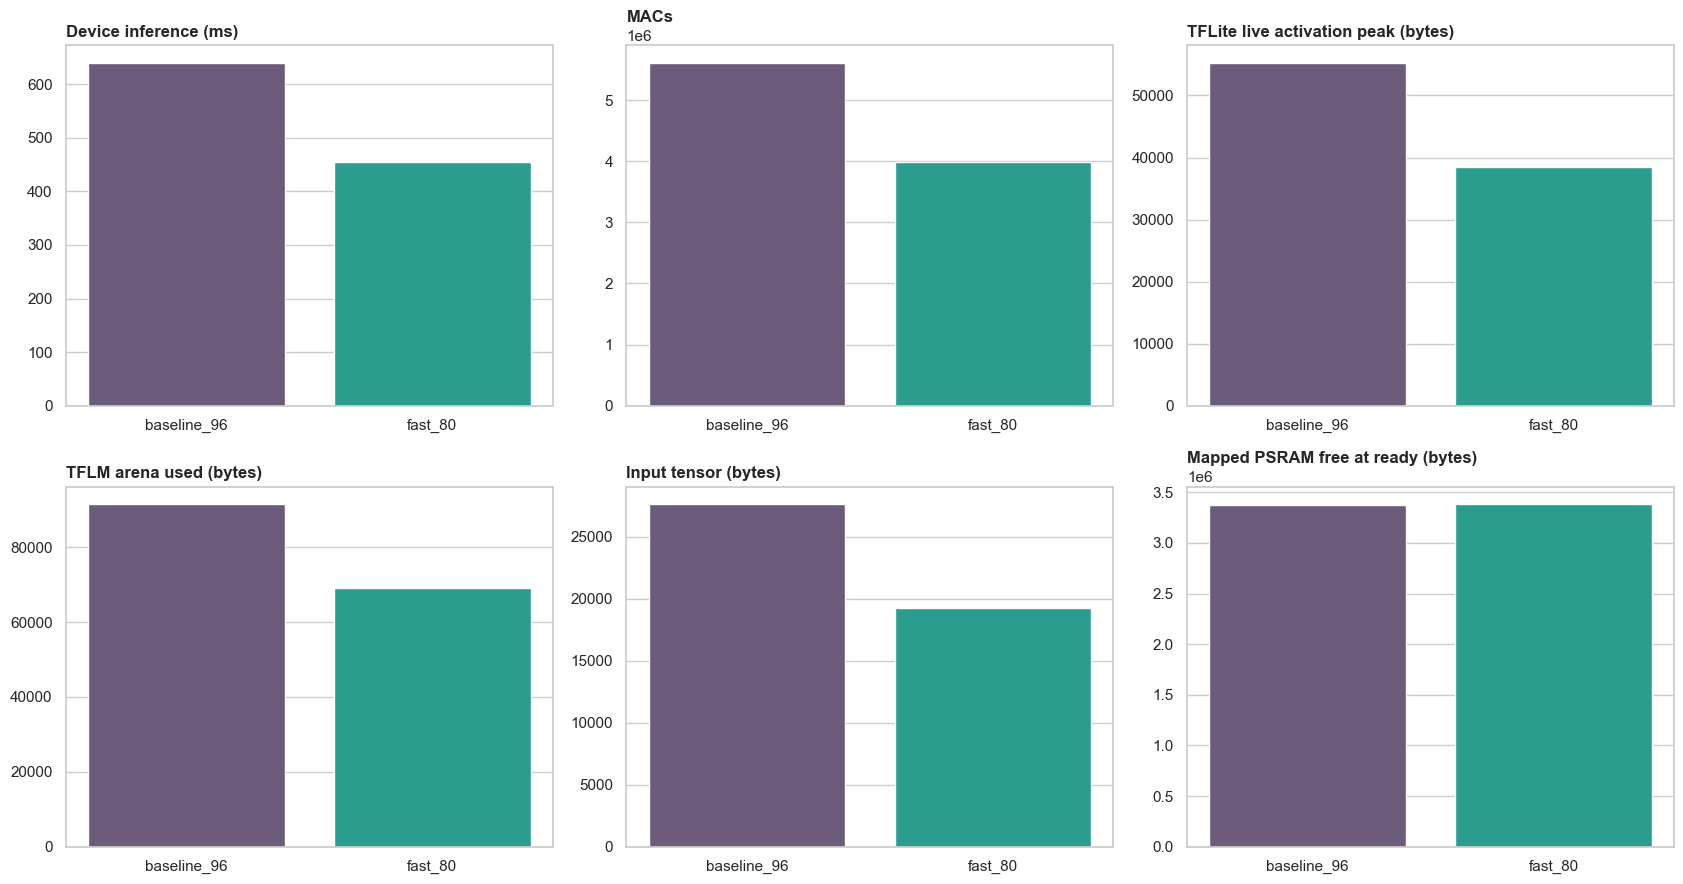

In [3]:
metrics = ['device_inference_ms', 'macs', 'tflite_live_activation_peak_bytes',
           'arena_used_bytes', 'input_tensor_bytes', 'psram_free_ready_bytes']
titles = ['Device inference (ms)', 'MACs', 'TFLite live activation peak (bytes)',
          'TFLM arena used (bytes)', 'Input tensor (bytes)', 'Mapped PSRAM free at ready (bytes)']
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for axis, metric, title in zip(axes.flat, metrics, titles):
    axis.bar(comparison.index, comparison[metric], color=['#6C5B7B', '#2A9D8F'])
    axis.set_title(title, loc='left', fontweight='bold')
    axis.grid(axis='x', visible=False)
plt.tight_layout()
fig.savefig(PROFILE_ROOT / 'whole_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

## RAM and tensor-arena comparison

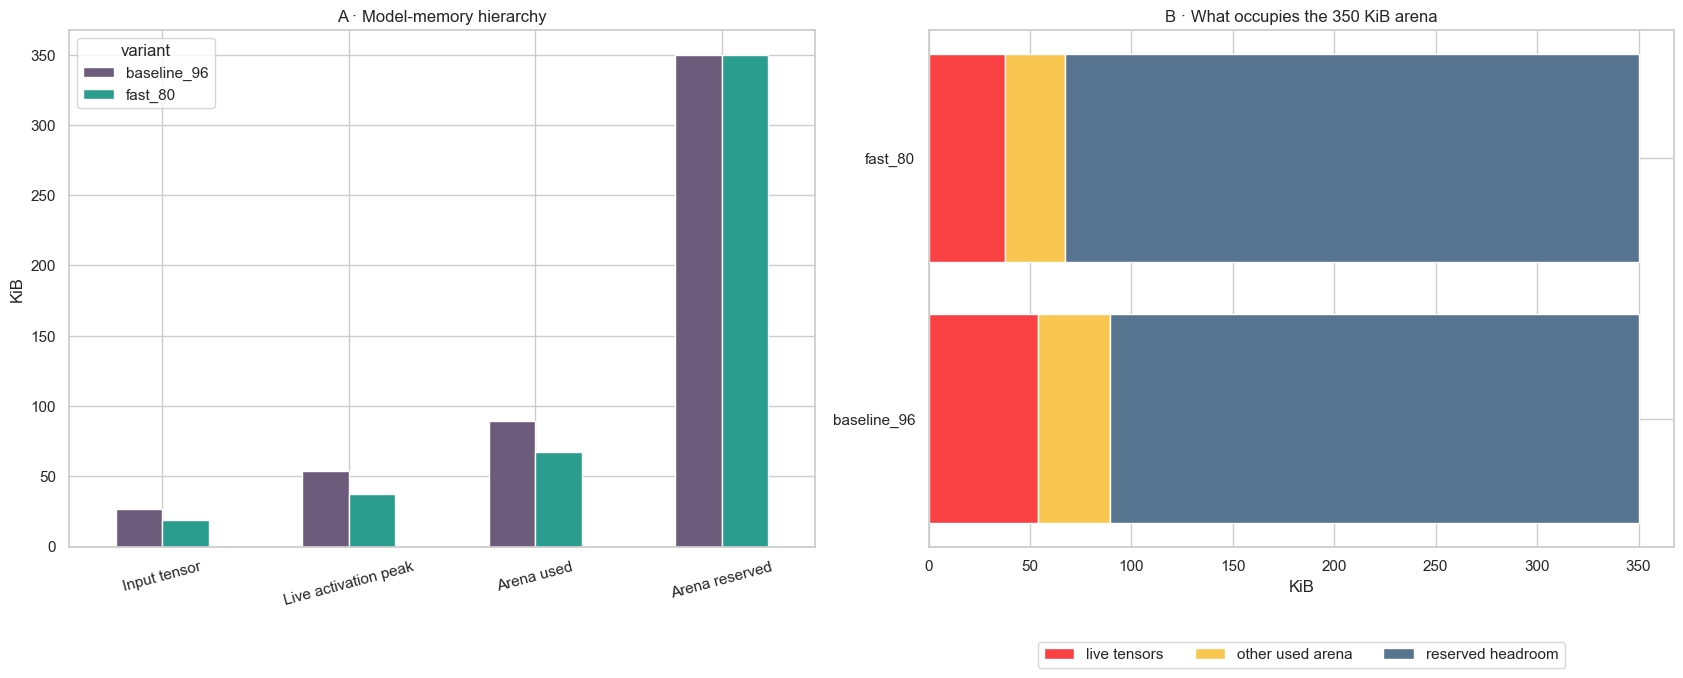

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
memory_metrics = ['input_tensor_bytes', 'tflite_live_activation_peak_bytes',
                  'arena_used_bytes', 'arena_reserved_bytes']
memory_labels = ['Input tensor', 'Live activation peak', 'Arena used', 'Arena reserved']
memory_values = comparison[memory_metrics].T / 1024
memory_values.index = memory_labels
memory_values.plot(kind='bar', ax=axes[0], color=['#6C5B7B', '#2A9D8F'])
axes[0].set(title='A · Model-memory hierarchy', ylabel='KiB', xlabel='')
axes[0].tick_params(axis='x', rotation=15)
colors = ['#F94144', '#F9C74F', '#577590']
for row_index, variant in enumerate(comparison.index):
    parts = [comparison.loc[variant, 'tflite_live_activation_peak_bytes'],
             comparison.loc[variant, 'arena_bytes_beyond_live_tensors'],
             comparison.loc[variant, 'arena_headroom_bytes']]
    left = 0
    for part, color, label in zip(parts, colors, ['live tensors', 'other used arena', 'reserved headroom']):
        axes[1].barh([variant], [part/1024], left=left/1024, color=color,
                     label=label if row_index == 0 else None)
        left += part
axes[1].set(title='B · What occupies the 350 KiB arena', xlabel='KiB')
axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.tight_layout()
fig.savefig(PROFILE_ROOT / 'memory_hierarchy_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

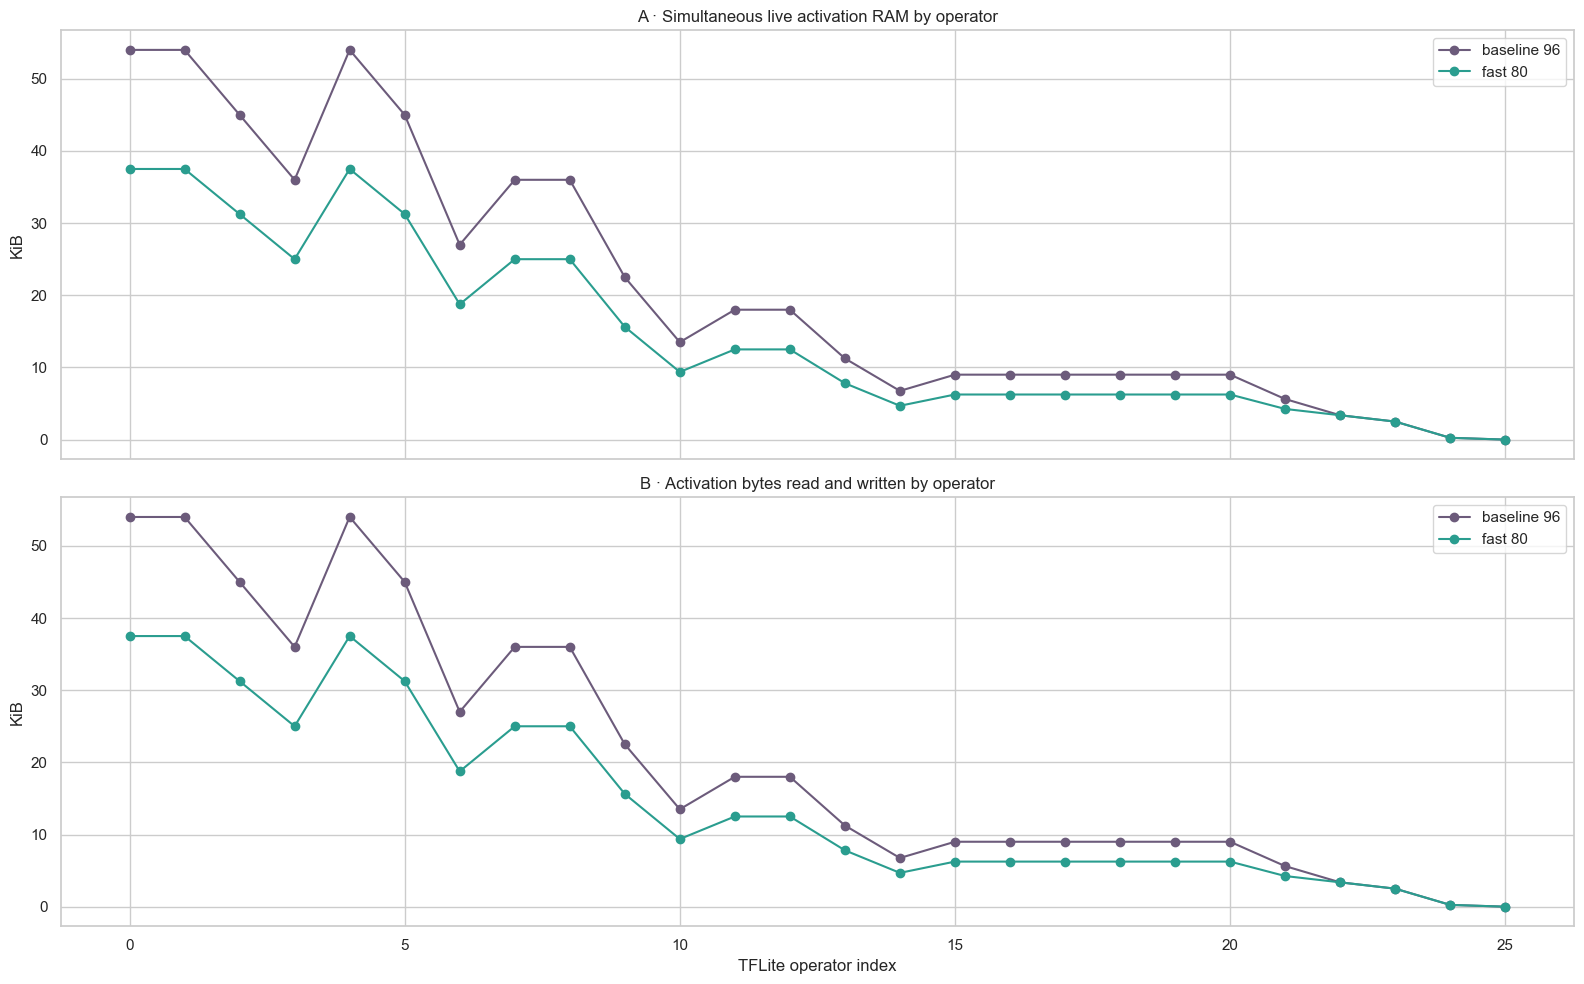

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
axes[0].plot(baseline_profile['index'], baseline_profile.live_activation_during_bytes/1024,
             marker='o', label='baseline 96', color='#6C5B7B')
axes[0].plot(fast_profile['index'], fast_profile.live_activation_during_bytes/1024,
             marker='o', label='fast 80', color='#2A9D8F')
axes[0].set(title='A · Simultaneous live activation RAM by operator', ylabel='KiB')
axes[0].legend()
axes[1].plot(baseline_profile['index'], baseline_profile.activation_io_bytes/1024,
             marker='o', label='baseline 96', color='#6C5B7B')
axes[1].plot(fast_profile['index'], fast_profile.activation_io_bytes/1024,
             marker='o', label='fast 80', color='#2A9D8F')
axes[1].set(title='B · Activation bytes read and written by operator',
            xlabel='TFLite operator index', ylabel='KiB')
axes[1].legend()
plt.tight_layout()
fig.savefig(PROFILE_ROOT / 'operator_memory_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

## Per-operator latency changes

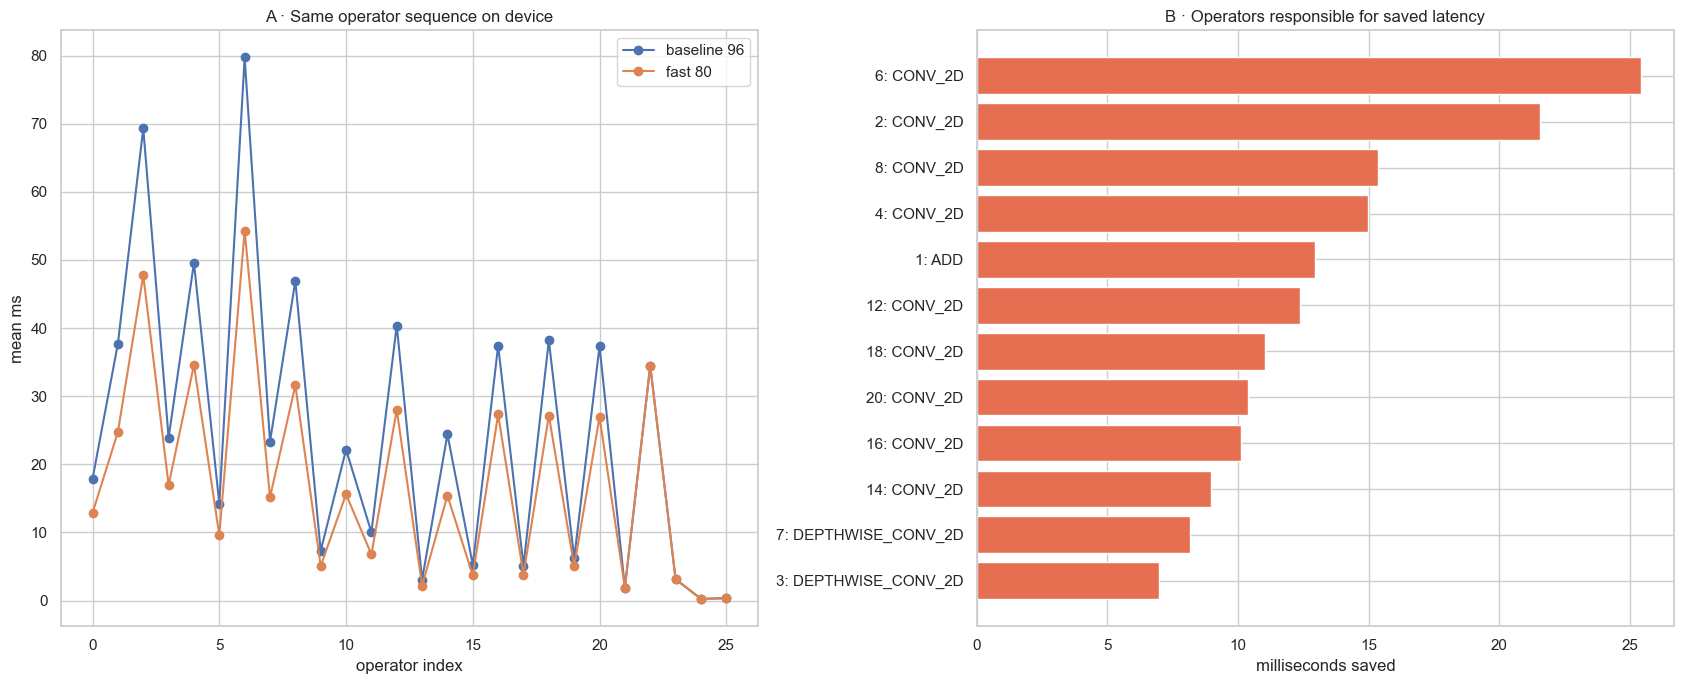

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
x = np.arange(len(operator_comparison))
axes[0].plot(x, operator_comparison.mean_ms_baseline_96, marker='o', label='baseline 96')
axes[0].plot(x, operator_comparison.mean_ms_fast_80, marker='o', label='fast 80')
axes[0].set(title='A · Same operator sequence on device', xlabel='operator index', ylabel='mean ms')
axes[0].legend()
saved = operator_comparison.nlargest(12, 'saved_ms').sort_values('saved_ms')
labels = saved.apply(lambda row: f"{int(row['index'])}: {row['operator']}", axis=1)
axes[1].barh(labels, saved.saved_ms, color='#E76F51')
axes[1].set(title='B · Operators responsible for saved latency', xlabel='milliseconds saved', ylabel='')
plt.tight_layout()
fig.savefig(PROFILE_ROOT / 'operator_latency_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

## Accuracy comparison

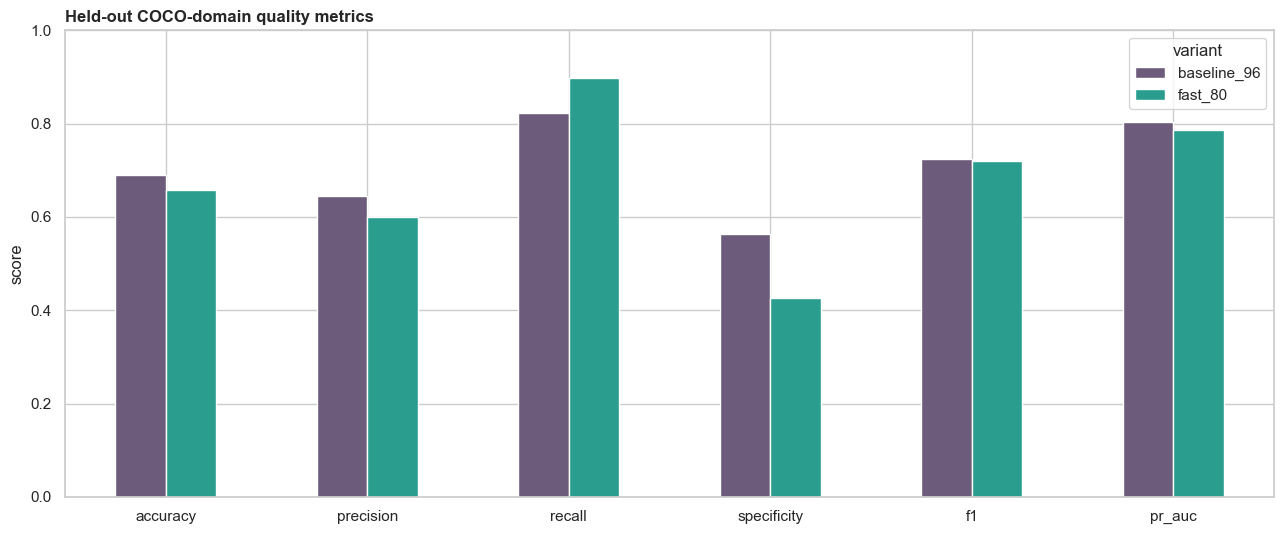

In [7]:
quality = comparison[['accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']].T
quality.plot(kind='bar', figsize=(13, 5.5), color=['#6C5B7B', '#2A9D8F'])
plt.title('Held-out COCO-domain quality metrics', loc='left', fontweight='bold')
plt.ylabel('score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PROFILE_ROOT / 'accuracy_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

## Decision for the next optimization

In [8]:
base = comparison.loc['baseline_96']
fast = comparison.loc['fast_80']
display(Markdown(f"""
- Input reduction lowers MACs by **{1-fast.macs/base.macs:.1%}** and measured device latency by **{1-fast.device_inference_ms/base.device_inference_ms:.1%}**.
- Peak live activation falls by **{1-fast.peak_live_int8_bytes/base.peak_live_int8_bytes:.1%}**; actual TFLM arena usage changes by **{1-fast.arena_used_bytes/base.arena_used_bytes:.1%}**.
- Exact fused-TFLite liveness peaks at **{base.tflite_live_activation_peak_bytes/1024:.1f} KiB** versus **{fast.tflite_live_activation_peak_bytes/1024:.1f} KiB**. Arena utilization falls from **{base.arena_utilization:.1%}** to **{fast.arena_utilization:.1%}**.
- Internal SRAM is unchanged at **{fast.internal_free_ready_bytes/1024:.1f} KiB free**, with only **{fast.internal_largest_ready_bytes/1024:.1f} KiB** in the largest contiguous block.
- F1 changes by **{fast.f1-base.f1:+.2%}** and recall by **{fast.recall-base.recall:+.2%}**.
- The next architecture target is ≤2.4M MACs, ≤25 KiB TFLite live activations, and ≤50 KiB actual arena usage for approximately 3 fps, followed by OV3660-domain fine-tuning and threshold calibration.
- Full report: `{PROFILE_ROOT / 'MODEL_VERSION_COMPARISON.md'}`.
"""))


- Input reduction lowers MACs by **28.9%** and measured device latency by **28.9%**.
- Peak live activation falls by **30.6%**; actual TFLM arena usage changes by **24.6%**.
- Exact fused-TFLite liveness peaks at **54.0 KiB** versus **37.5 KiB**. Arena utilization falls from **25.6%** to **19.3%**.
- Internal SRAM is unchanged at **65.3 KiB free**, with only **60.0 KiB** in the largest contiguous block.
- F1 changes by **-0.33%** and recall by **+7.44%**.
- The next architecture target is ≤2.4M MACs, ≤25 KiB TFLite live activations, and ≤50 KiB actual arena usage for approximately 3 fps, followed by OV3660-domain fine-tuning and threshold calibration.
- Full report: `/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/device_profiles/MODEL_VERSION_COMPARISON.md`.
